Loading required package: ggplot2



Testando função e coletando dados para o gráfico...

Tamanho:        10 | Tempo: 0.005799 segundos
Tamanho:       100 | Tempo: 0.000021 segundos
Tamanho:      1000 | Tempo: 0.000072 segundos
Tamanho:     10000 | Tempo: 0.000713 segundos
Tamanho:    100000 | Tempo: 0.006821 segundos
Tamanho:   1000000 | Tempo: 0.066631 segundos


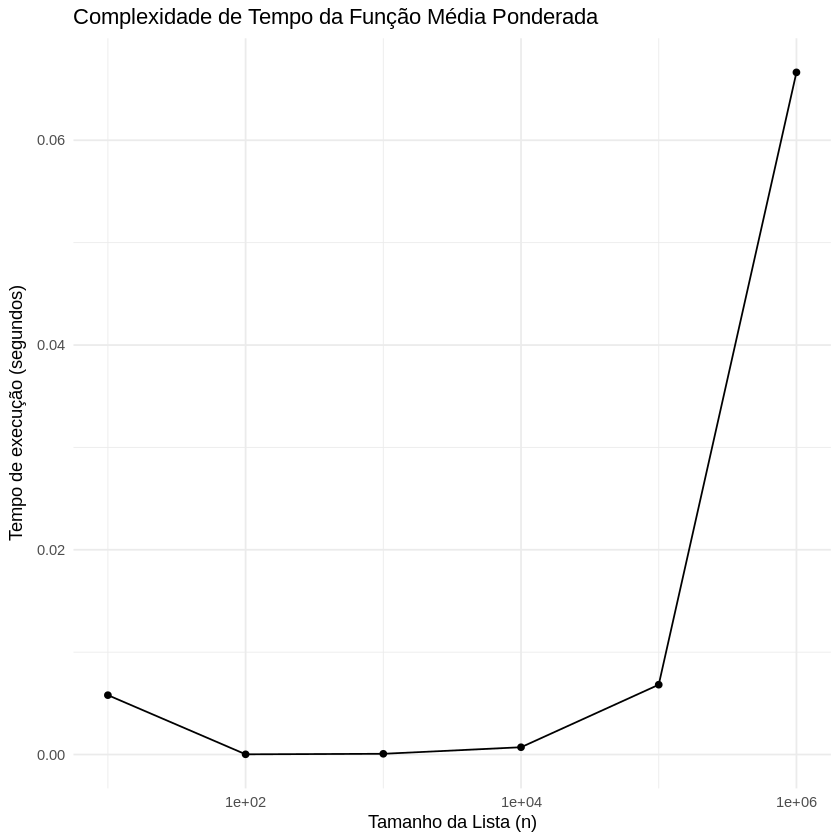

In [1]:
# Carregando a biblioteca para gráficos (equivalente ao matplotlib)
if (!require(ggplot2)) install.packages("ggplot2")
library(ggplot2)

# 1. Definição da função de média ponderada
weighted_mean_custom <- function(list_of_numbers, weights) {
  running_total <- 0
  for (i in 1:length(list_of_numbers)) {
    running_total <- running_total + (list_of_numbers[i] * weights[i])
  }
  return(running_total / sum(weights))
}

# 2. Função auxiliar para medir tempo
medir_tempo <- function(tamanho) {
  numeros <- runif(tamanho, min = 1, max = 100)
  pesos <- runif(tamanho, min = 1, max = 10)

  inicio <- Sys.time()
  resultado <- weighted_mean_custom(numeros, pesos)
  fim <- Sys.time()

  # Retorna a diferença em segundos
  return(as.numeric(difftime(fim, inicio, units = "secs")))
}

# 3. Listas (Vetores) para guardar os tamanhos e tempos
tamanhos <- c(10, 100, 1000, 10000, 100000, 1000000)
tempos <- c()

cat("Testando função e coletando dados para o gráfico...\n\n")

for (tamanho in tamanhos) {
  tempo_execucao <- medir_tempo(tamanho)
  tempos <- c(tempos, tempo_execucao)

  # Formatando a saída no console
  cat(sprintf("Tamanho: %9d | Tempo: %.6f segundos\n", tamanho, tempo_execucao))
}

# 4. Criando o gráfico
df_plot <- data.frame(tamanhos = tamanhos, tempos = tempos)

ggplot(df_plot, aes(x = tamanhos, y = tempos)) +
  geom_line() +
  geom_point() +
  scale_x_log10() + # Escala logarítmica para o eixo X
  labs(title = "Complexidade de Tempo da Função Média Ponderada",
       x = "Tamanho da Lista (n)",
       y = "Tempo de execução (segundos)") +
  theme_minimal()

### Configurando R no Google Colab com `rpy2`

Primeiro, precisamos instalar a biblioteca `rpy2`, que permite a interação entre Python e R.

In [7]:
%%capture
!pip install rpy2


Agora podemos carregar a extensão `rpy2.ipython` e usar a *magic command* `%%R` para executar código R em uma célula Python. Dentro de uma célula `%%R`, você pode instalar pacotes R da mesma forma que faria em um ambiente R normal.

In [8]:
%%R
# Carregando a biblioteca para gráficos (equivalente ao matplotlib)
# Verifique se o pacote já está instalado e, se não, instale-o.
if (!require(ggplot2)) {
  install.packages("ggplot2", repos = "http://cran.us.r-project.org")
}
library(ggplot2)

# Exemplo: Instalar outro pacote R (se necessário)
# if (!require(dplyr)) {
#   install.packages("dplyr", repos = "http://cran.us.r-project.org")
# }
# library(dplyr)

print("Pacotes R carregados com sucesso!")

UsageError: Cell magic `%%R` not found.


Com `ggplot2` (ou qualquer outro pacote R) instalado e carregado usando `%%R`, você pode usar as funções do R em suas células `%%R` subsequentes. O código original que você forneceu estava em R e, ao executá-lo em uma célula `%%R`, ele deverá funcionar corretamente.